# Biomass gasification hydrogen NPV simulation

Run the Monte Carlo hydrogen model at 100,000 tH2/year. The notebook shows NPV, LNM, and LCOH distributions, NPV sign counts, and mean annual cost components. Greenfield conceptual biomass gasification without CCS. Biomass uses the shared biomass-energy price distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from hydrogen.hydrogen_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_hydrogen_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution

pd.options.display.float_format = "{:,.3f}".format

In [2]:
TECHNOLOGY = "biomass_gasification"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

simulation = simulate_hydrogen_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()

,run_id,technology,technology_type,retrofit_bau_mode,annual_output_th2,lifetime_years,capex_eur_per_th2,fixed_opex_eur_per_th2,variable_opex_eur_per_th2,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_th2,present_value_total_cost_eur,lcoh_eur_per_th2,levelized_net_margin_eur_per_th2
0,0,biomass_gasification,absolute,not_applicable,"100,000.000",25,"1,091.425",59.224,772.055,biomass,...,"12,130,411.591",0.000,0.000,"176,414,657.266","573,585,342.734","6,013,752,654.390","1,067,477.619","1,992,329,487.052","1,866.390","5,633.610"
1,1,biomass_gasification,absolute,not_applicable,"100,000.000",25,"1,398.208",66.392,769.429,biomass,...,"9,460,138.994",0.000,0.000,"242,933,882.803","507,066,117.197","5,272,996,562.833","1,067,477.619","2,733,085,578.608","2,560.321","4,939.679"
2,2,biomass_gasification,absolute,not_applicable,"100,000.000",25,"1,063.522",58.970,772.959,biomass,...,"14,495,110.219",0.000,0.000,"212,267,635.950","537,732,364.050","5,633,820,483.318","1,067,477.619","2,372,261,658.123","2,222.306","5,277.694"
3,3,biomass_gasification,absolute,not_applicable,"100,000.000",25,"1,416.928",77.640,804.007,biomass,...,"7,279,264.268",0.000,0.000,"234,537,020.502","515,462,979.498","5,360,759,176.027","1,067,477.619","2,645,322,965.414","2,478.106","5,021.894"
4,4,biomass_gasification,absolute,not_applicable,"100,000.000",25,963.982,62.053,805.474,biomass,...,"15,984,541.958",0.000,0.000,"199,519,640.304","550,480,359.696","5,779,856,455.500","1,067,477.619","2,226,225,685.942","2,085.501","5,414.499"


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcoh_eur_per_th2 = results["lcoh_eur_per_th2"]
levelized_net_margin_eur_per_th2 = results["levelized_net_margin_eur_per_th2"]

summary = pd.concat([
    npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename("NPV million EUR"),
    levelized_net_margin_eur_per_th2.describe(percentiles=[0.05, 0.5, 0.95]).rename("LNM EUR/tH2"),
    lcoh_eur_per_th2.describe(percentiles=[0.05, 0.5, 0.95]).rename("LCOH EUR/tH2"),
], axis=1)
npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame([
    {"NPV category": "Non-negative (NPV >= 0)", "Count": npv_signs["non_negative_count"], "Share": npv_signs["non_negative_share"]},
    {"NPV category": "Negative (NPV < 0)", "Count": npv_signs["negative_count"], "Share": 1 - npv_signs["non_negative_share"]},
])
display(summary, npv_sign_summary)

,NPV million EUR,LNM EUR/tH2,LCOH EUR/tH2
count,"100,000.000","100,000.000","100,000.000"
mean,"5,549.813","5,198.997","2,301.003"
std,287.904,269.705,269.705
min,"4,351.581","4,076.508","1,610.622"
5%,"5,037.631","4,719.191","1,893.370"
50%,"5,572.157","5,219.929","2,280.071"
95%,"5,984.952","5,606.630","2,780.809"
max,"6,286.779","5,889.378","3,423.492"


,NPV category,Count,Share
0,Non-negative (NPV >= 0),100000,1.000
1,Negative (NPV < 0),0,0.000


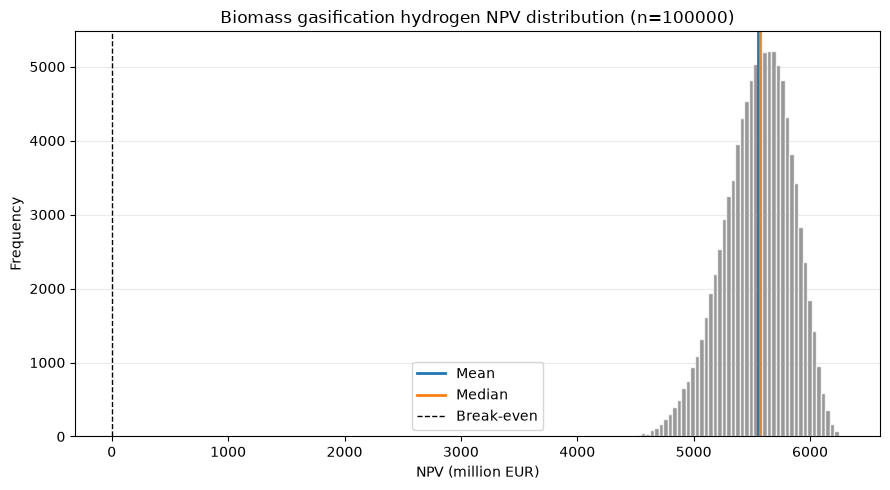

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"Biomass gasification hydrogen NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()

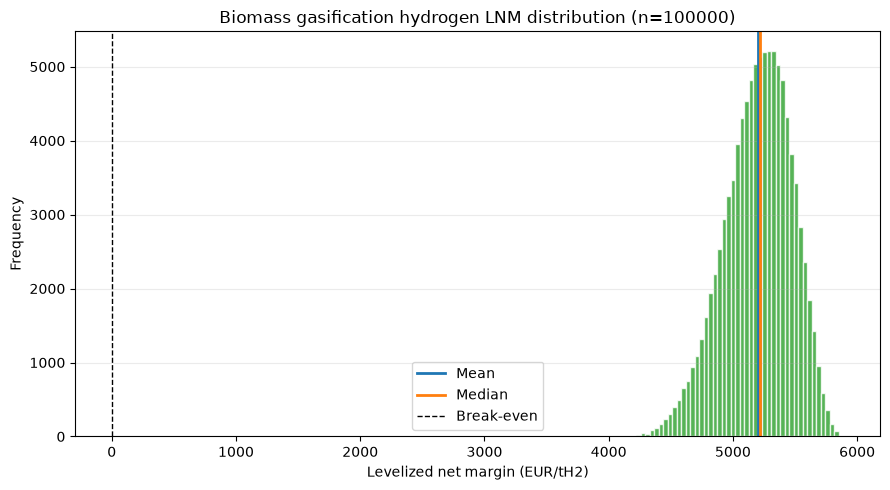

In [5]:
plot_financial_metric_distribution(
    levelized_net_margin_eur_per_th2,
    title=f"Biomass gasification hydrogen LNM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized net margin (EUR/tH2)",
    color="tab:green",
    show_break_even=True,
)
plt.show()

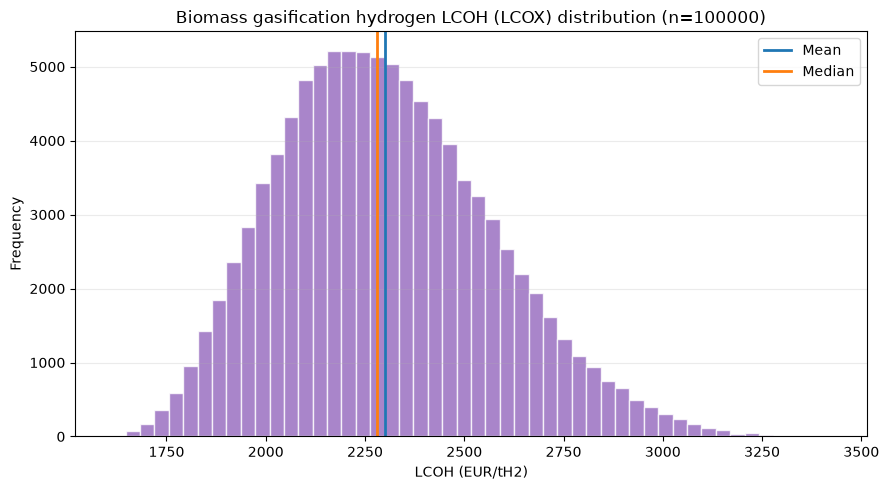

In [6]:
plot_financial_metric_distribution(
    lcoh_eur_per_th2,
    title=f"Biomass gasification hydrogen LCOH (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOH (EUR/tH2)",
    color="tab:purple",
)
plt.show()

In [7]:
annual_columns = [
    "annual_revenue_eur",
    "annual_fixed_opex_eur",
    "annual_variable_opex_eur",
    "annual_natural_gas_cost_eur",
    "annual_biomethane_cost_eur",
    "annual_biomass_cost_eur",
    "annual_fuel_cost_eur",
    "annual_electricity_cost_eur",
    "annual_transport_and_storage_cost_eur",
    "annual_emissions_cost_eur",
    "annual_net_cash_flow_eur",
]
(results[annual_columns] / 1_000_000).mean().rename("Mean annual value, million EUR")

annual_revenue_eur                      750.000
annual_fixed_opex_eur                     7.030
annual_variable_opex_eur                 78.801
annual_natural_gas_cost_eur               0.000
annual_biomethane_cost_eur                0.000
annual_biomass_cost_eur                 119.772
annual_fuel_cost_eur                    119.772
annual_electricity_cost_eur              12.471
annual_transport_and_storage_cost_eur     0.000
annual_emissions_cost_eur                 0.000
annual_net_cash_flow_eur                531.925
Name: Mean annual value, million EUR, dtype: float64